## 1. Dataset Loading

In [38]:
# Import Libraries
import numpy as np
import pandas as pd
import warnings # 警告を無視するためのライブラリ
import gc # ガベージコレクション（不要なオブジェクトをメモリから削除するためのライブラリ）
import time # 時間計測のためのライブラリ
from itertools import combinations # 組み合わせを生成するためのライブラリ

from sklearn.metrics import roc_auc_score # ROC AUCスコアを計算するためのライブラリ
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from scipy.stats import rankdata
from scipy.optimize import minimize, Bounds
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore') # 警告を無視する設定
pd.set_option('display.max_columns', 100) # データフレームの表示設定（最大列数を100に設定）
plt.style.use('seaborn-v0_8-whitegrid') # MatplotlibのスタイルをSeabornの白背景グリッドに設定
sns.set_palette('husl') # Seabornのカラーパレットを設定

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [39]:
# ===============================
# 学習の基本設定をまとめるクラス
# ここを変えると、後続セルの挙動が一括で変わる
# ===============================
class CFG: # 設定をまとめるクラス
    TARGET = 'Churn'
    N_FOLDS = 20         # Nested Cross Validationでデータを20分割して、19で学習・1で検証を20回まわす（外側CVの分割数（最終評価用））
    INNER_FOLDS = 5      # 分割した学習データをさらに学習データと検証データに分割するTarget Encoding用の内側CV分割数
    RANDOM_SEED = 42     # 乱数シード（再現性のため固定）
    
    # データ読み込みパス（環境に合わせて変更）
    TRAIN_PATH = '../data/train.csv'
    TEST_PATH = '../data/test.csv'
    ORIGINAL_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    # 欠損補完があればその基準、ORIG_proba 系の特徴量、分布比較系の特徴量を作る材料に使う。学習データ本体ではなく、特徴量作成の参考データ

# bi-gram / tri-gram 2列結合、3列結合の新たな特徴を作る候補のカテゴリ
TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

# XGBoostのハイパーパラメータ
XGB_PARAMS = {
    'n_estimators': 50000,            # 木の最大本数（早期終了で実際は手前で止まる）
    'learning_rate': 0.0063,          # 学習率（小さいほどゆっくり学習）
    'max_depth': 5,                   # 1本の木の深さ
    'subsample': 0.81,                # 行サンプリング率
    'colsample_bytree': 0.32,         # 列サンプリング率
    'min_child_weight': 6,            # 葉を分割する最小重み
    'reg_alpha': 3.5017,              # L1正則化
    'reg_lambda': 1.2925,             # L2正則化
    'gamma': 0.790,                   # 分割に必要な最小損失減少
    'random_state': CFG.RANDOM_SEED,
    'early_stopping_rounds': 500,     # 改善が止まったら打ち切る
    'objective': 'binary:logistic',   # 2値分類
    'eval_metric': 'auc',             # 評価指標
    'enable_categorical': True,       # カテゴリ型を有効化
    'device': 'cuda',                 # GPU使用（GPUがなければ'cpu'）
    'verbosity': 0,
}

# CatBoostのハイパーパラメータ
CB_PARAMS = {
    'n_estimators': 50000,
    'learning_rate': 0.05,
    'eval_metric': 'AUC',
    'max_depth': 5,
    'auto_class_weights': 'Balanced', # クラス不均衡を自動補正
    'random_state': CFG.RANDOM_SEED,
    'early_stopping_rounds': 100,
    'verbose': False
}

# モデル本体を辞書でまとめて作成
# 後でループ処理しやすくするため 'XGB', 'CB' というキーで管理
models = {
    'XGB': XGBClassifier(**XGB_PARAMS),
    'CB': CatBoostClassifier(**CB_PARAMS)
}

print("Configuration set!")

Configuration set!


In [40]:
# ===============================
# データ読み込みと前処理（学習前の準備）
# ===============================
from pathlib import Path

print("Loading datasets...")

# 1) 学習用データ・テストデータ・参照用の元データを読み込む
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
orig = pd.read_csv(CFG.ORIGINAL_PATH)

# 2) 目的変数 Churn を文字列(Yes/No) -> 数値(1/0) に変換する
train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET] = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)

# 3) orig の TotalCharges を数値型に直し、欠損は中央値で補完する
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)

# 4) 元データに customerID がある場合は学習に不要なので削除する
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

# 5) 提出ファイル作成で使う id を退避しておく
train_ids = train['id'].copy()
test_ids = test['id'].copy()

# 6) 最後にデータサイズを確認する（想定どおり読めたかチェック）
print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Original Shape: {orig.shape}")

Loading datasets...
Train Shape : (594194, 21)
Test Shape  : (254655, 20)
Original Shape: (7043, 20)


## 2. Exploratory Data Analysis (EDA)

In [41]:
# Dataset Overview
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
display(train.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(train.dtypes.to_frame('dtype'))

TRAINING DATA OVERVIEW


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1



DATA TYPES
                    dtype
id                  int64
gender             object
SeniorCitizen       int64
Partner            object
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
OnlineSecurity     object
OnlineBackup       object
DeviceProtection   object
TechSupport        object
StreamingTV        object
StreamingMovies    object
Contract           object
PaperlessBilling   object
PaymentMethod      object
MonthlyCharges    float64
TotalCharges      float64
Churn               int64


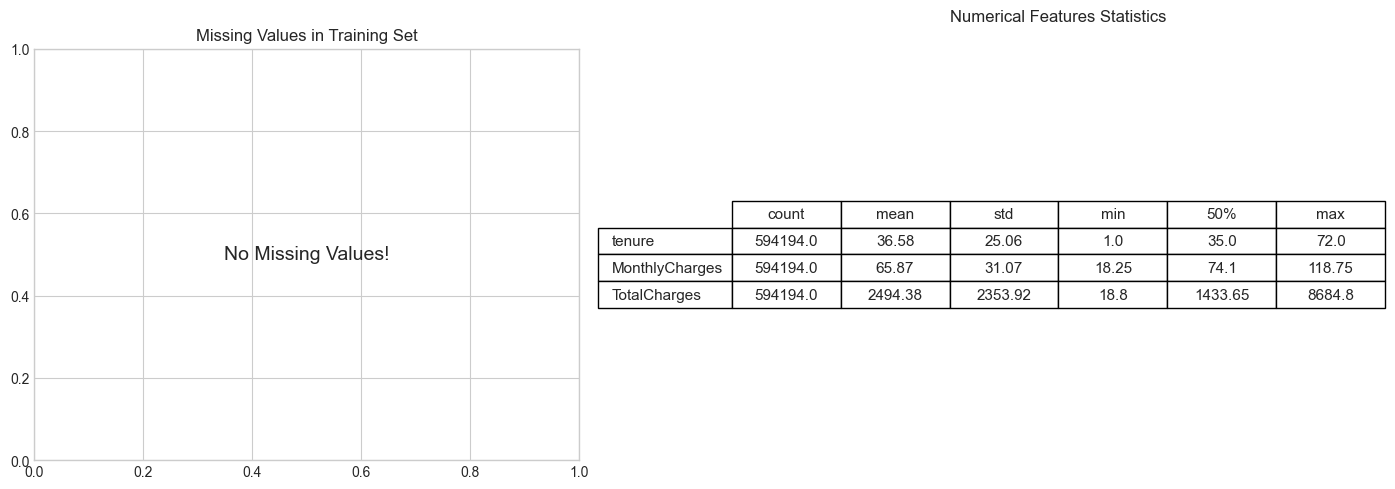

In [42]:
# ===============================
# 欠損値の確認 + 数値列の要約統計を1枚で可視化
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1行2列のグラフ領域を作成

# 1) 学習データの欠損数を列ごとに集計
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0]

# 2) 欠損があれば棒グラフ、なければメッセージを表示
if len(train_missing) > 0:
    axes[0].barh(train_missing.index, train_missing.values, color='coral')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values in Training Set')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Set')

# 3) 代表的な数値列の要約統計（件数・平均・標準偏差・最小・中央値・最大）を作成
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_df = train[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

# 4) 右側の領域に表として表示
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.round(2).values,
                       rowLabels=stats_df.index,
                       colLabels=stats_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
axes[1].set_title('Numerical Features Statistics', fontsize=12, pad=20)

# 5) レイアウトを整えて表示
plt.tight_layout()
plt.show()

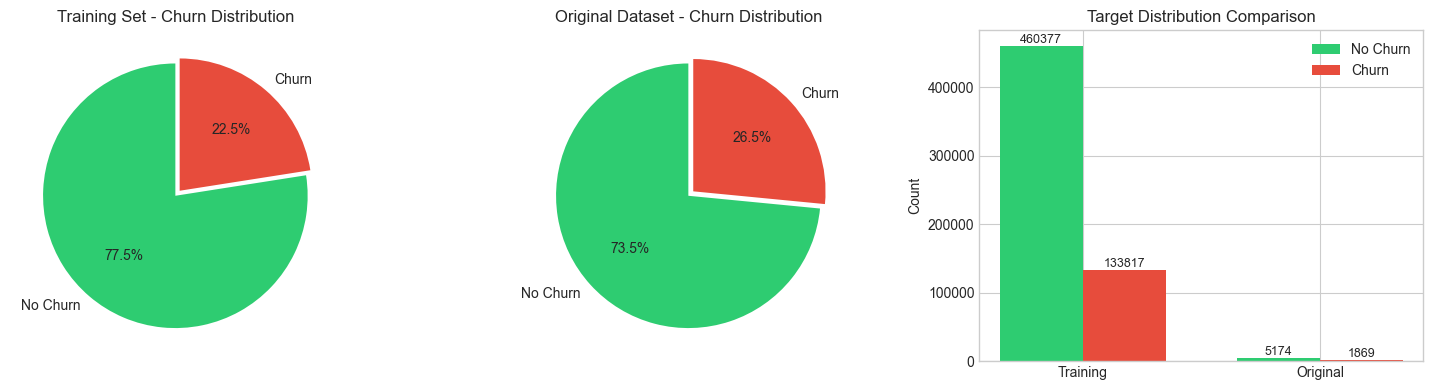


Churn Rate - Training: 22.52%
Churn Rate - Original: 26.54%


In [43]:
# Target Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training set target
train_churn = train[CFG.TARGET].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(train_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Training Set - Churn Distribution')

# Original dataset target
orig_churn = orig[CFG.TARGET].value_counts()
axes[1].pie(orig_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Original Dataset - Churn Distribution')

# Comparison bar chart
x = np.arange(2)
width = 0.35
bars1 = axes[2].bar(x - width/2, [train_churn[0], orig_churn[0]], width, label='No Churn', color='#2ecc71')
bars2 = axes[2].bar(x + width/2, [train_churn[1], orig_churn[1]], width, label='Churn', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Training', 'Original'])
axes[2].set_ylabel('Count')
axes[2].set_title('Target Distribution Comparison')
axes[2].legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nChurn Rate - Training: {train[CFG.TARGET].mean()*100:.2f}%")
print(f"Churn Rate - Original: {orig[CFG.TARGET].mean()*100:.2f}%")

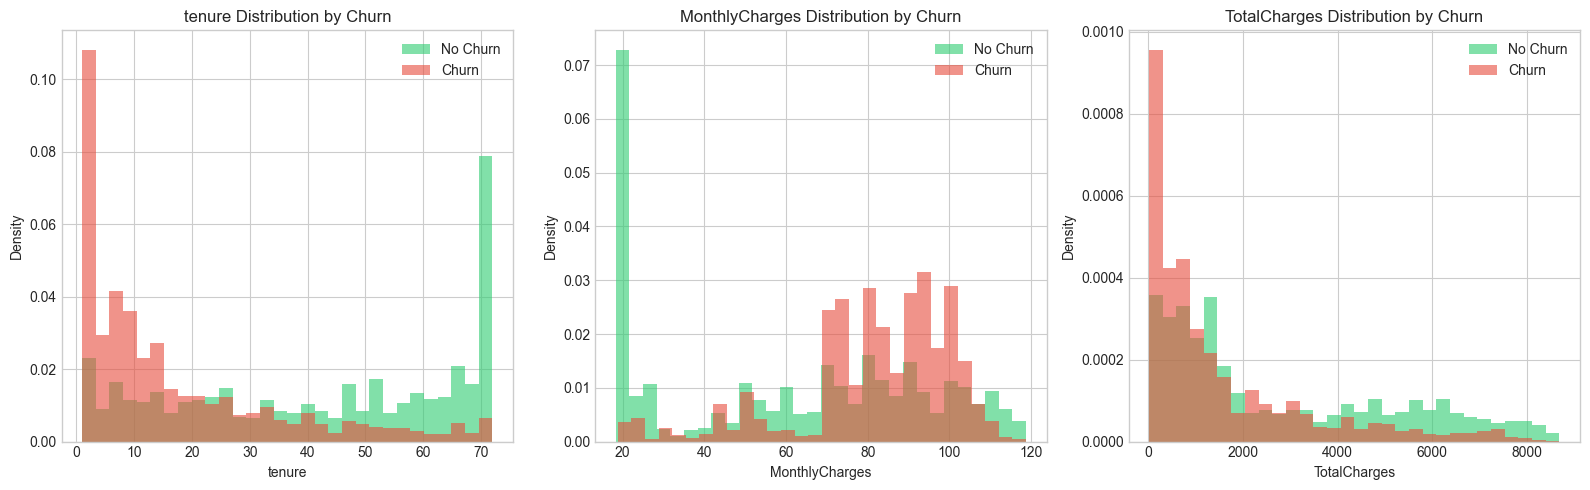


Key Observations:
  - Tenure: Churners tend to have shorter tenure
  - MonthlyCharges: Churners often have higher monthly charges
  - TotalCharges: Churners typically have lower total charges (correlated with tenure)


In [8]:
# Numerical Features Distribution by Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for churn_val, label, color in [(0, 'No Churn', '#2ecc71'), (1, 'Churn', '#e74c3c')]:
        data = train[train[CFG.TARGET] == churn_val][col]
        axes[idx].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{col} Distribution by Churn')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Tenure: Churners tend to have shorter tenure")
print("  - MonthlyCharges: Churners often have higher monthly charges")
print("  - TotalCharges: Churners typically have lower total charges (correlated with tenure)")

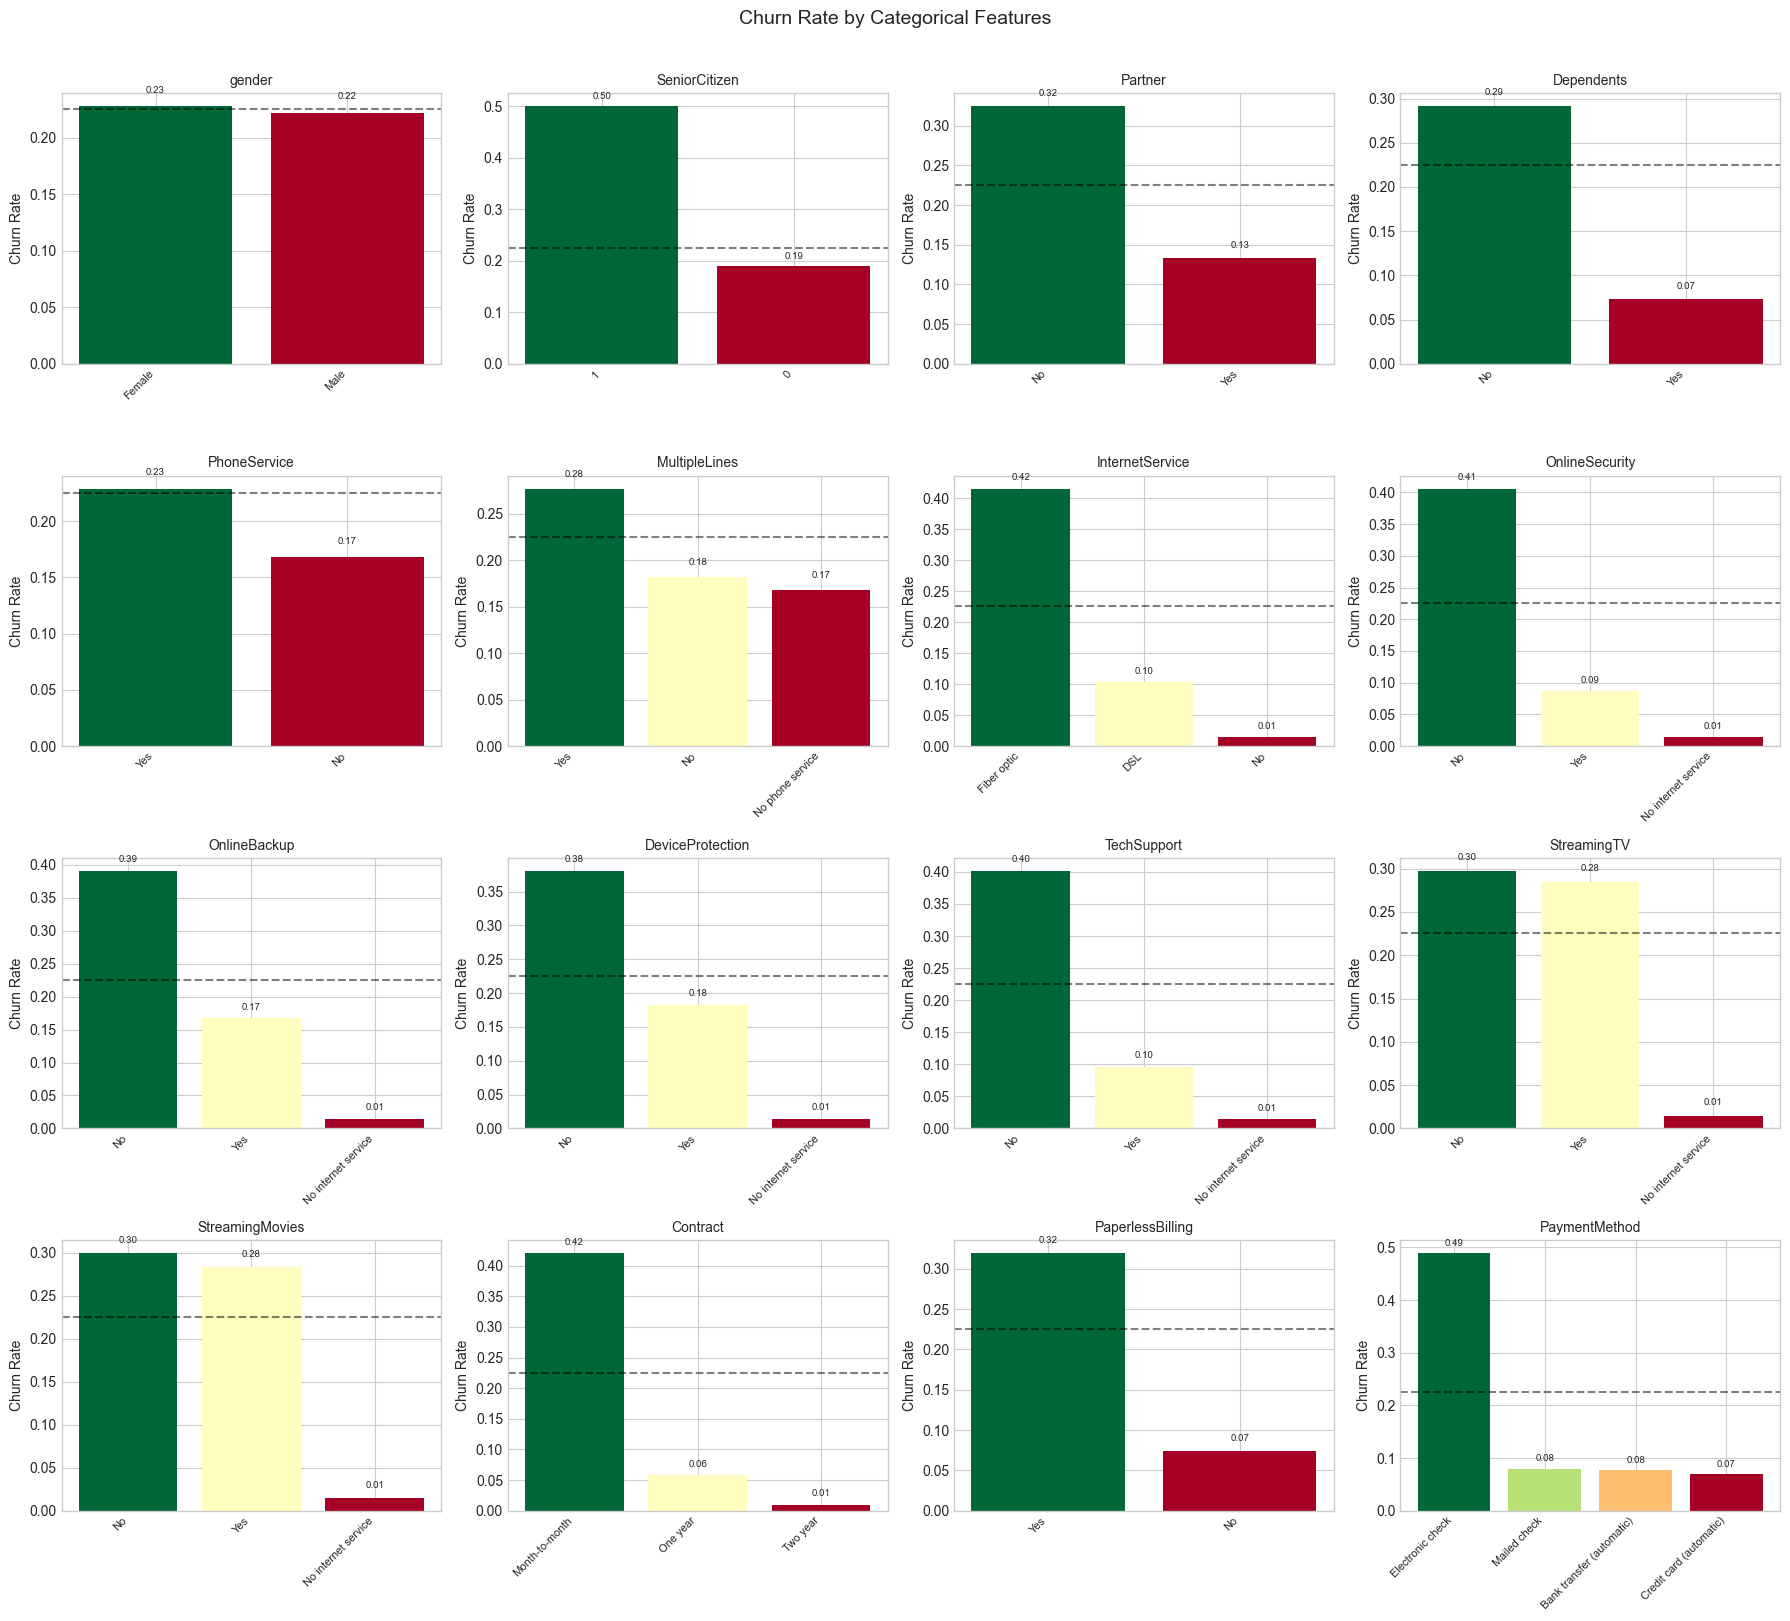

In [9]:
# Categorical Features Analysis
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(CATS):
    # Calculate churn rate by category
    churn_rate = train.groupby(col)[CFG.TARGET].mean().sort_values(ascending=False)
    
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(churn_rate)))
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors)
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].axhline(y=train[CFG.TARGET].mean(), color='black', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                      f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

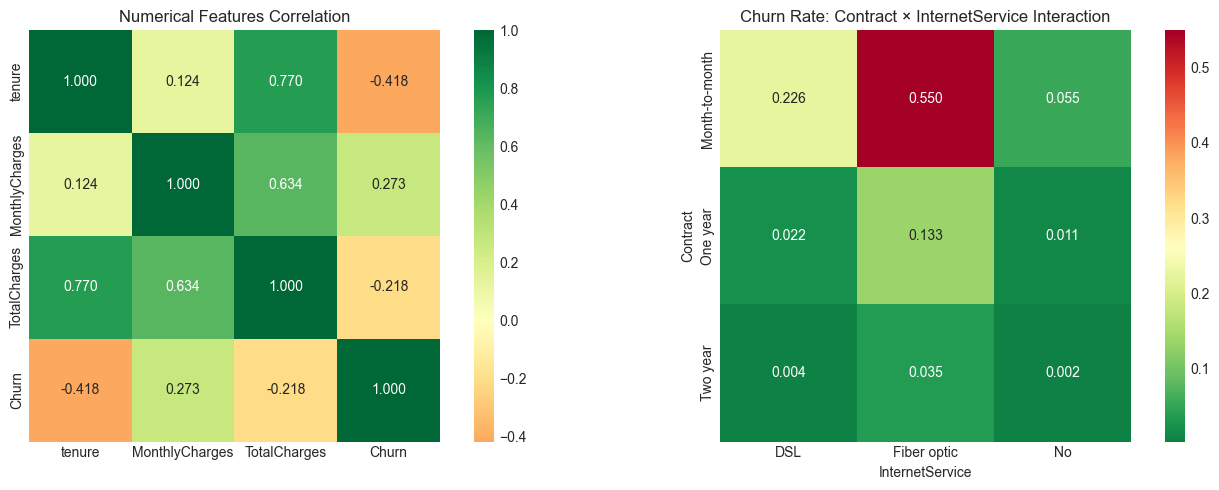


Note: strong> interaction between Contract type and InternetService!
This justifies using bi-gram/tri-gram composite features.


In [ ]:
# ===============================
# 相関と相互作用の可視化（特徴量設計の根拠づくり）
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 数値列と目的変数の相関を確認する
#    ・tenure / MonthlyCharges / TotalCharges はこのデータの主要な連続値
#    ・Churn との線形な関係の強さをまず把握する
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = train[num_cols + [CFG.TARGET]].corr()  # 目的変数も含めて相関行列を計算
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn',
    center=0,
    ax=axes[0],
    fmt='.3f',
    square=True
 )
axes[0].set_title('Numerical Features Correlation')

# 2) カテゴリ同士（Contract × InternetService）の相互作用を確認する
#    各組み合わせごとの平均Churn率をピボットで可視化し、
#    単独の列だけでは見えにくい「組み合わせ効果」を探す
pivot = train.pivot_table(
    values=CFG.TARGET,
    index='Contract',
    columns='InternetService',
    aggfunc='mean'
 )
sns.heatmap(
    pivot,
    annot=True,
    cmap='RdYlGn_r',
    center=0.26,
    ax=axes[1],
    fmt='.3f',
    square=True
 )
axes[1].set_title('Churn Rate: Contract x InternetService Interaction')

plt.tight_layout()
plt.show()

print("\nNote: strong interaction between Contract type and InternetService!")
print("This justifies using bi-gram/tri-gram composite features.")

## 3. Feature Engineering & Model Training

In [11]:
# Define Feature Groups
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']

NEW_NUMS = []
NUM_AS_CAT = []

print("Feature Engineering Pipeline Started...")
print("="*60)

Feature Engineering Pipeline Started...


In [12]:
# 1. Frequency Encoding
print("[1/7] Creating Frequency Encoding features...")
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
print(f"    Created {len(NUMS)} frequency features")

[1/7] Creating Frequency Encoding features...
    Created 3 frequency features


In [13]:
# 2. Arithmetic Interactions
print("[2/7] Creating Arithmetic Interaction features...")
for df in [train, test, orig]:
    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')
NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(f"    Created 3 arithmetic features")

[2/7] Creating Arithmetic Interaction features...
    Created 3 arithmetic features


In [14]:
# 3. Service Counts
print("[3/7] Creating Service Count features...")
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test, orig]:
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
    df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
print(f"    Created 3 service count features")

[3/7] Creating Service Count features...
    Created 3 service count features


In [15]:
# 4. ORIG_proba Mapping
print("[4/7] Creating ORIG_proba features (target probability from original data)...")
for col in CATS + NUMS:
    tmp = orig.groupby(col)[CFG.TARGET].mean()
    _name = f"ORIG_proba_{col}"
    train = train.merge(tmp.rename(_name), on=col, how="left")
    test = test.merge(tmp.rename(_name), on=col, how="left")
    for df in [train, test]:
        df[_name] = df[_name].fillna(0.5).astype('float32')
    NEW_NUMS.append(_name)
print(f"    Created {len(CATS + NUMS)} ORIG_proba features")

[4/7] Creating ORIG_proba features (target probability from original data)...
    Created 19 ORIG_proba features


In [16]:
# 5. Distribution Features
print("[5/7] Creating Distribution Features (percentile ranks, z-scores)...")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0 
            else ((values - mu) / sigma).astype('float32'))

orig_churner_tc    = orig.loc[orig[CFG.TARGET] == 1, 'TotalCharges'].values
orig_nonchurner_tc = orig.loc[orig[CFG.TARGET] == 0, 'TotalCharges'].values
orig_tc            = orig['TotalCharges'].values
orig_is_mc_mean    = orig.groupby('InternetService')['MonthlyCharges'].mean()

for df in [train, test]:
    tc = df['TotalCharges'].values
    df['pctrank_nonchurner_TC']  = pctrank_against(tc, orig_nonchurner_tc)
    df['pctrank_churner_TC']     = pctrank_against(tc, orig_churner_tc)
    df['pctrank_orig_TC']        = pctrank_against(tc, orig_tc)
    df['zscore_churn_gap_TC'] = (np.abs(zscore_against(tc, orig_churner_tc)) - 
                                 np.abs(zscore_against(tc, orig_nonchurner_tc))).astype('float32')
    df['zscore_nonchurner_TC'] = zscore_against(tc, orig_nonchurner_tc)
    df['pctrank_churn_gap_TC'] = (pctrank_against(tc, orig_churner_tc) - 
                                  pctrank_against(tc, orig_nonchurner_tc)).astype('float32')
    df['resid_IS_MC'] = (df['MonthlyCharges'] - df['InternetService'].map(orig_is_mc_mean).fillna(0)).astype('float32')
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref = orig.loc[orig['InternetService'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_IS_TC'] = vals
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref = orig.loc[orig['Contract'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_C_TC'] = vals

DIST_FEATURES = [
    'pctrank_nonchurner_TC', 'zscore_churn_gap_TC', 'pctrank_churn_gap_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'zscore_nonchurner_TC',
    'pctrank_orig_TC', 'pctrank_churner_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES
print(f"    Created {len(DIST_FEATURES)} distribution features")

[5/7] Creating Distribution Features (percentile ranks, z-scores)...
    Created 9 distribution features


In [17]:
# 6. Quantile Distance Features
print("[6/7] Creating Quantile Distance Features...")
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)
    for df in [train, test]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_To_{q_label}'] = (df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']).astype('float32')

QDIST_FEATURES = [
    'qdist_gap_To_q50', 'dist_To_ch_q50', 'dist_To_nc_q50',
    'dist_To_nc_q25', 'qdist_gap_To_q25',
    'dist_To_nc_q75', 'dist_To_ch_q75', 'qdist_gap_To_q75'
]
NEW_NUMS += QDIST_FEATURES
print(f"    Created {len(QDIST_FEATURES)} quantile distance features")

[6/7] Creating Quantile Distance Features...
    Created 8 quantile distance features


In [18]:
# 7. Numericals as Categories
print("[7/7] Creating Numericals-as-Categories features...")
for col in NUMS:
    _new = f'CAT_{col}'
    NUM_AS_CAT.append(_new)
    for df in [train, test]:
        df[_new] = df[col].astype(str).astype('category')
print(f"    Created {len(NUMS)} numerical-as-category features")

[7/7] Creating Numericals-as-Categories features...
    Created 3 numerical-as-category features


In [19]:
# New Digit Features
DIGIT_FEATURES = [
    # Tenure
    'tenure_first_digit','tenure_last_digit','tenure_second_digit',
    'tenure_mod10','tenure_mod12','tenure_num_digits',
    'tenure_is_multiple_10','tenure_rounded_10','tenure_dev_from_round10',

    # MonthlyCharges
    'mc_first_digit','mc_last_digit','mc_second_digit',
    'mc_mod10','mc_mod100','mc_num_digits',
    'mc_is_multiple_10','mc_is_multiple_50',
    'mc_rounded_10','mc_fractional','mc_dev_from_round10',

    # TotalCharges
    'tc_first_digit','tc_last_digit','tc_second_digit',
    'tc_mod10','tc_mod100','tc_num_digits',
    'tc_is_multiple_10','tc_is_multiple_100',
    'tc_rounded_100','tc_fractional','tc_dev_from_round100',

    # Derived
    'tenure_years','tenure_months_in_year',
    'mc_per_digit','tc_per_digit'
]

for df in [train, test]:

    # Tenure digits
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit'] = t_str.str[0].astype(int)
    df['tenure_last_digit'] = t_str.str[-1].astype(int)
    df['tenure_second_digit'] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tenure_mod10'] = df['tenure'] % 10
    df['tenure_mod12'] = df['tenure'] % 12
    df['tenure_num_digits'] = t_str.str.len()

    df['tenure_is_multiple_10'] = (df['tenure'] % 10 == 0).astype('float32')

    df['tenure_rounded_10'] = np.round(df['tenure']/10)*10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])

    # MonthlyCharges
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '')

    df['mc_first_digit'] = mc_str.str[0].astype(int)
    df['mc_last_digit'] = mc_str.str[-1].astype(int)
    df['mc_second_digit'] = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['mc_mod10'] = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100'] = np.floor(df['MonthlyCharges']) % 100

    df['mc_num_digits'] = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()

    df['mc_is_multiple_10'] = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50'] = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')

    df['mc_rounded_10'] = np.round(df['MonthlyCharges']/10)*10
    df['mc_fractional'] = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = abs(df['MonthlyCharges'] - df['mc_rounded_10'])

    # TotalCharges
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '')

    df['tc_first_digit'] = tc_str.str[0].astype(int)
    df['tc_last_digit'] = tc_str.str[-1].astype(int)
    df['tc_second_digit'] = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tc_mod10'] = np.floor(df['TotalCharges']) % 10
    df['tc_mod100'] = np.floor(df['TotalCharges']) % 100

    df['tc_num_digits'] = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()

    df['tc_is_multiple_10'] = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100'] = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')

    df['tc_rounded_100'] = np.round(df['TotalCharges']/100)*100
    df['tc_fractional'] = df['TotalCharges'] - np.floor(df['TotalCharges'])

    df['tc_dev_from_round100'] = abs(df['TotalCharges'] - df['tc_rounded_100'])

    # Derived
    df['tenure_years'] = df['tenure'] // 12
    df['tenure_months_in_year'] = df['tenure'] % 12

    df['mc_per_digit'] = df['MonthlyCharges']/(df['mc_num_digits']+0.001)
    df['tc_per_digit'] = df['TotalCharges']/(df['tc_num_digits']+0.001)

NEW_NUMS += DIGIT_FEATURES
print(f"    Created {len(DIGIT_FEATURES)} digital Numerical features")

    Created 35 digital Numerical features


In [20]:
# Create Bi-gram and Tri-gram Composite Categorical Features
print("\n" + "="*60)
print("Creating Bi-gram / Tri-gram Composite Features...")
print("="*60)

BIGRAM_COLS = []
TRIGRAM_COLS = []

# Bi-grams: all pairs from top 6 cats = C(6,2) = 15 pairs
print(f"\nCreating Bi-gram features from top {len(TOP_CATS_FOR_NGRAM)} categoricals:")
print(f"  Columns: {TOP_CATS_FOR_NGRAM}")
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')
    BIGRAM_COLS.append(col_name)

print(f"  Created {len(BIGRAM_COLS)} bi-gram features")

# Tri-grams: top 4 cats only to limit = C(4,3) = 4 triples
TOP4 = TOP_CATS_FOR_NGRAM[:4]
print(f"\nCreating Tri-gram features from top 4 categoricals:")
print(f"  Columns: {TOP4}")
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)).astype('category')
    TRIGRAM_COLS.append(col_name)

print(f"  Created {len(TRIGRAM_COLS)} tri-gram features")

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
print(f"\nTotal N-gram features: {len(NGRAM_COLS)}")


Creating Bi-gram / Tri-gram Composite Features...

Creating Bi-gram features from top 6 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
  Created 15 bi-gram features

Creating Tri-gram features from top 4 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
  Created 4 tri-gram features

Total N-gram features: 19


In [21]:
# Feature Summary
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS
TE_NGRAM_COLUMNS = NGRAM_COLS
TO_REMOVE = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ['std', 'min', 'max']

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Total Features: {len(FEATURES)}")
print(f"  - Numerical:          {len(NUMS)}")
print(f"  - Categorical:        {len(CATS)}")
print(f"  - Engineered Numerical: {len(NEW_NUMS)}")
print(f"  - Num-as-Cat:         {len(NUM_AS_CAT)}")
print(f"  - Bi-gram:            {len(BIGRAM_COLS)}")
print(f"  - Tri-gram:           {len(TRIGRAM_COLS)}")


FEATURE ENGINEERING COMPLETE
Total Features: 121
  - Numerical:          3
  - Categorical:        16
  - Engineered Numerical: 80
  - Num-as-Cat:         3
  - Bi-gram:            15
  - Tri-gram:           4


In [22]:
# Model Training with 10-Fold Cross-Validation
print("\n" + "="*60)
print(f"TRAINING WITH {CFG.N_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

np.random.seed(CFG.RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
skf_inner = StratifiedKFold(n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)

oof = {}
pred = {}
fold_scores = {}
fi = {}
for model_name in models.keys():
    oof[model_name] = np.zeros(len(train))
    pred[model_name] = np.zeros(len(test))
    fold_scores[model_name] = []
    fi[model_name] = pd.DataFrame()

t0 = time.time()

for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[CFG.TARGET])):
    print(f"\n{'='*50}")
    print(f"Fold {i+1}/{CFG.N_FOLDS}")
    print(f"{'='*50}")
    
    X_tr  = train.loc[train_idx, FEATURES + [CFG.TARGET]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, CFG.TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, CFG.TARGET].values
    X_te  = test[FEATURES].reset_index(drop=True).copy()
    
    # ─── Inner KFold TE for ORIGINAL categoricals ────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr, FEATURES + [CFG.TARGET]].copy()
        X_va2 = X_tr.loc[in_va, FEATURES].copy()
        for col in TE_COLUMNS:
            tmp = X_tr2.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                X_tr.loc[in_va, c] = X_va2[c].values.astype("float32")
                
    # Full-fold TE stat for val/test (original cats)
    for col in TE_COLUMNS:
        tmp = X_tr.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_te  = X_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [X_tr, X_val, X_te]:
                df[c] = df[c].fillna(0)
    
    # ─── Inner KFold TE for N-GRAM categoricals ───────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr].copy()
        X_va2 = X_tr.loc[in_va].copy()
        for col in TE_NGRAM_COLUMNS:
            ng_te = X_tr2.groupby(col, observed=False)[CFG.TARGET].mean()
            ng_name = f"TE_ng_{col}"
            mapped = X_va2[col].astype(str).map(ng_te)
            X_tr.loc[in_va, ng_name] = pd.to_numeric(mapped, errors='coerce').fillna(0.5).astype('float32').values
    
    # Full-fold TE for n-grams on val/test
    for col in TE_NGRAM_COLUMNS:
        ng_te = X_tr.groupby(col, observed=False)[CFG.TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_te[ng_name]  = pd.to_numeric(X_te[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        if ng_name in X_tr.columns:
            X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors='coerce').fillna(0.5).astype('float32')
        else:
            X_tr[ng_name] = 0.5
                
    # sklearn TargetEncoder (Mean) for original cats
    TE_MEAN_COLS = [f'TE_{col}' for col in TE_COLUMNS]
    te = TargetEncoder(cv=CFG.INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=CFG.RANDOM_SEED)
    X_tr[TE_MEAN_COLS] = te.fit_transform(X_tr[TE_COLUMNS], y_tr)
    X_val[TE_MEAN_COLS] = te.transform(X_val[TE_COLUMNS])
    X_te[TE_MEAN_COLS] = te.transform(X_te[TE_COLUMNS])
    
    # Prepare — remove raw categoricals
    for df in [X_tr, X_val, X_te]:
        for c in CATS + NUM_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype(str).astype("category")
        df.drop(columns=[c for c in TO_REMOVE if c in df.columns], inplace=True, errors='ignore')
    X_tr.drop(columns=[CFG.TARGET], inplace=True, errors='ignore')
    COLS_XGB = X_tr.columns
    
    if i == 0:
        n_feats = len(COLS_XGB)
        n_ngram_feats = sum(1 for c in COLS_XGB if c.startswith('TE_ng_'))
        print(f"\n  Features for models: {n_feats} ({n_ngram_feats} from n-gram TE)")
    
    # Train models
    for model_name, model in models.items():
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=1000)
        
        # Store feature importance
        fold_imp = pd.DataFrame({'feature': COLS_XGB, f'importance_fold_{i+1}': model.feature_importances_})
        fi[model_name] = pd.merge(fi[model_name], fold_imp, on='feature', how='outer') if i > 0 else fold_imp
        
        # Record Results
        oof[model_name][val_idx] = model.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, oof[model_name][val_idx])
        fold_scores[model_name].append(fold_auc)
        
        fold_test_p = model.predict_proba(X_te[COLS_XGB])[:, 1]
        pred[model_name] += fold_test_p / CFG.N_FOLDS
        
        print(f"   Fold {i+1} AUC: {fold_auc:.5f} | Time: {(time.time()-t0)/60:.1f} min")
        del model
    
    del X_tr, X_val, X_te, y_tr, y_val
    gc.collect()

print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")


TRAINING WITH 20-FOLD CROSS-VALIDATION

Fold 1/20

  Features for models: 178 (19 from n-gram TE)
[0]	validation_0-auc:0.90445
[1000]	validation_0-auc:0.93141
[2000]	validation_0-auc:0.93654
[3000]	validation_0-auc:0.94062
[4000]	validation_0-auc:0.94344
[5000]	validation_0-auc:0.94522
[6000]	validation_0-auc:0.94647
[7000]	validation_0-auc:0.94742
[8000]	validation_0-auc:0.94802
[9000]	validation_0-auc:0.94851
[10000]	validation_0-auc:0.94885
[11000]	validation_0-auc:0.94918
[12000]	validation_0-auc:0.94936
[13000]	validation_0-auc:0.94951
[14000]	validation_0-auc:0.94961
[15000]	validation_0-auc:0.94964
[15342]	validation_0-auc:0.94964
   Fold 1 AUC: 0.94965 | Time: 5.0 min
0:	test: 0.9005183	best: 0.9005183 (0)	total: 99.7ms	remaining: 1h 23m 5s
1000:	test: 0.9479186	best: 0.9479221 (995)	total: 26.5s	remaining: 21m 38s
2000:	test: 0.9491149	best: 0.9491221 (1950)	total: 51.3s	remaining: 20m 31s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9493988672
bestIte

## 4. Model Blend

In [28]:
def objective(w):
    oof_ensemble = np.zeros(len(train))
    for i, model_name in enumerate(models.keys()):
        oof_ensemble += oof[model_name] * w[i]
    return -roc_auc_score(train[CFG.TARGET], oof_ensemble)
 
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = Bounds(0, 1)
 
w0 = np.ones(len(models)) / len(models)

# 等式制約(sum(w)=1)を扱えるSLSQPで最適化
result = minimize(
    objective,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000}
 )

if not result.success:
    print(f"[WARN] weight optimization did not fully converge: {result.message}")

w = result.x
print('Model weights', w)

oof_ensemble = np.zeros(len(train))
pred_ensemble = np.zeros(len(test))
for i, model_name in enumerate(models.keys()):
    oof_ensemble += oof[model_name] * w[i]
    pred_ensemble += pred[model_name] * w[i]

Model weights [0.50000136 0.49999864]


## 5. Evaluation Metrics

In [29]:
# Calculate Overall Metrics
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report

overall_auc = roc_auc_score(train[CFG.TARGET], oof_ensemble)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nEnsemble CV AUC:  {overall_auc:.5f}\n")

for model_name in models.keys():
    print("="*60)
    print(f"Model", model_name)
    overall_auc = roc_auc_score(train[CFG.TARGET], oof[model_name])
    mean_score = np.mean(fold_scores[model_name])
    std_score = np.std(fold_scores[model_name])
    print(f"\nModel CV AUC:  {overall_auc:.5f}")
    print(f"Mean Fold AUC:   {mean_score:.5f} +/- {std_score:.5f}")
    print(f"\nPer-Fold Scores:")
    for i, score in enumerate(fold_scores[model_name]):
        print(f"  Fold {i+1:2d}: {score:.5f}")

MODEL PERFORMANCE SUMMARY

Ensemble CV AUC:  0.94851

Model XGB

Model CV AUC:  0.94833
Mean Fold AUC:   0.94834 +/- 0.00121

Per-Fold Scores:
  Fold  1: 0.94965
  Fold  2: 0.94768
  Fold  3: 0.94714
  Fold  4: 0.94858
  Fold  5: 0.95098
  Fold  6: 0.94845
  Fold  7: 0.94633
  Fold  8: 0.94971
  Fold  9: 0.94733
  Fold 10: 0.94753
  Fold 11: 0.94935
  Fold 12: 0.94874
  Fold 13: 0.94981
  Fold 14: 0.94885
  Fold 15: 0.94774
  Fold 16: 0.94909
  Fold 17: 0.94815
  Fold 18: 0.94737
  Fold 19: 0.94828
  Fold 20: 0.94601
Model CB

Model CV AUC:  0.94822
Mean Fold AUC:   0.94822 +/- 0.00122

Per-Fold Scores:
  Fold  1: 0.94940
  Fold  2: 0.94785
  Fold  3: 0.94728
  Fold  4: 0.94895
  Fold  5: 0.95052
  Fold  6: 0.94827
  Fold  7: 0.94577
  Fold  8: 0.94985
  Fold  9: 0.94737
  Fold 10: 0.94718
  Fold 11: 0.94946
  Fold 12: 0.94830
  Fold 13: 0.94990
  Fold 14: 0.94836
  Fold 15: 0.94793
  Fold 16: 0.94879
  Fold 17: 0.94814
  Fold 18: 0.94713
  Fold 19: 0.94802
  Fold 20: 0.94601


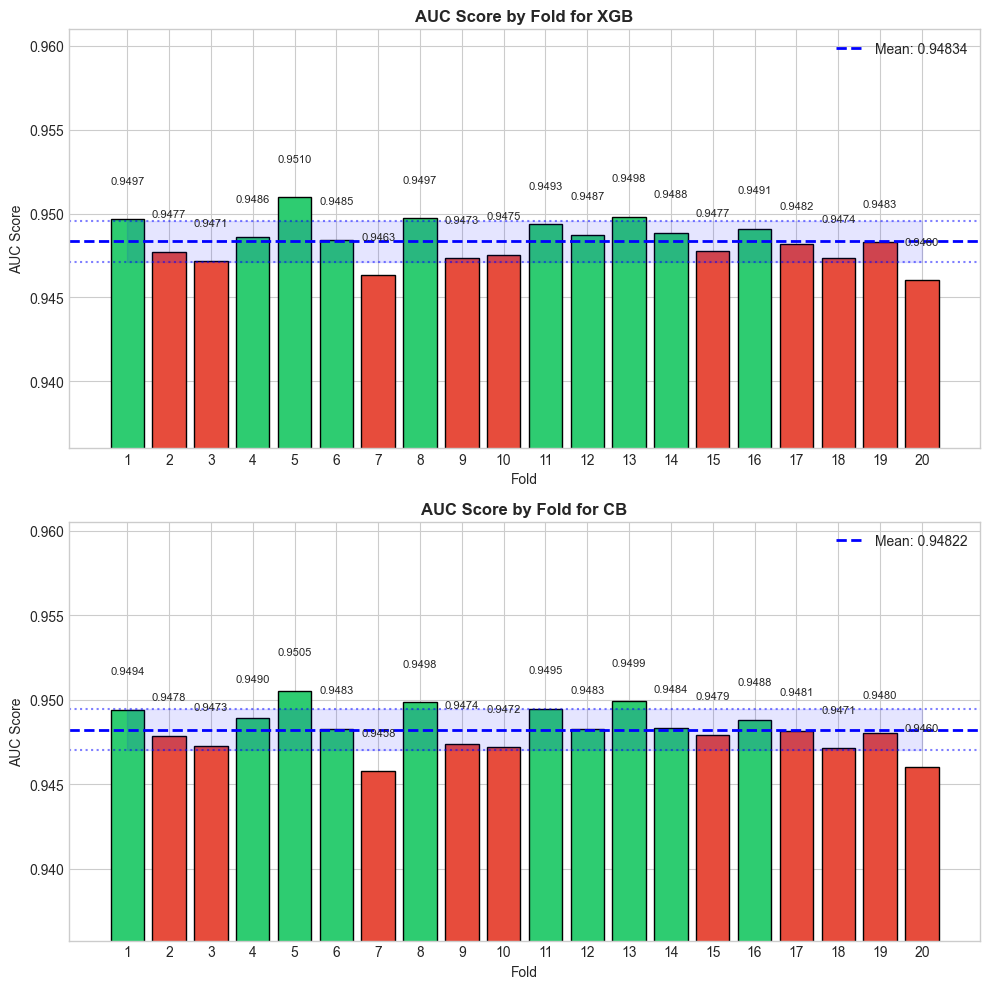

In [30]:
# Visualization: Fold Performance
fig, axes = plt.subplots(len(models), 1, figsize=(10, 5 * len(models)))

# モデル数が1のときも同じ書き方で処理できるようにする
if len(models) == 1:
    axes = [axes]

for i, model_name in enumerate(models.keys()):
    model_scores = fold_scores[model_name]
    mean_score = np.mean(model_scores)
    std_score = np.std(model_scores)

    # 1. Fold AUC Scores
    ax1 = axes[i]
    colors = ['#2ecc71' if s >= mean_score else '#e74c3c' for s in model_scores]
    bars = ax1.bar(range(1, CFG.N_FOLDS + 1), model_scores, color=colors, edgecolor='black')
    ax1.axhline(y=mean_score, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.5f}')
    ax1.axhline(y=mean_score + std_score, color='blue', linestyle=':', alpha=0.5)
    ax1.axhline(y=mean_score - std_score, color='blue', linestyle=':', alpha=0.5)
    ax1.fill_between(range(1, CFG.N_FOLDS + 1), mean_score - std_score, mean_score + std_score, alpha=0.1, color='blue')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('AUC Score')
    ax1.set_title('AUC Score by Fold for ' + model_name, fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, CFG.N_FOLDS + 1))
    ax1.legend()
    ax1.set_ylim([min(model_scores) - 0.01, max(model_scores) + 0.01])
    
    for bar, score in zip(bars, model_scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{score:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

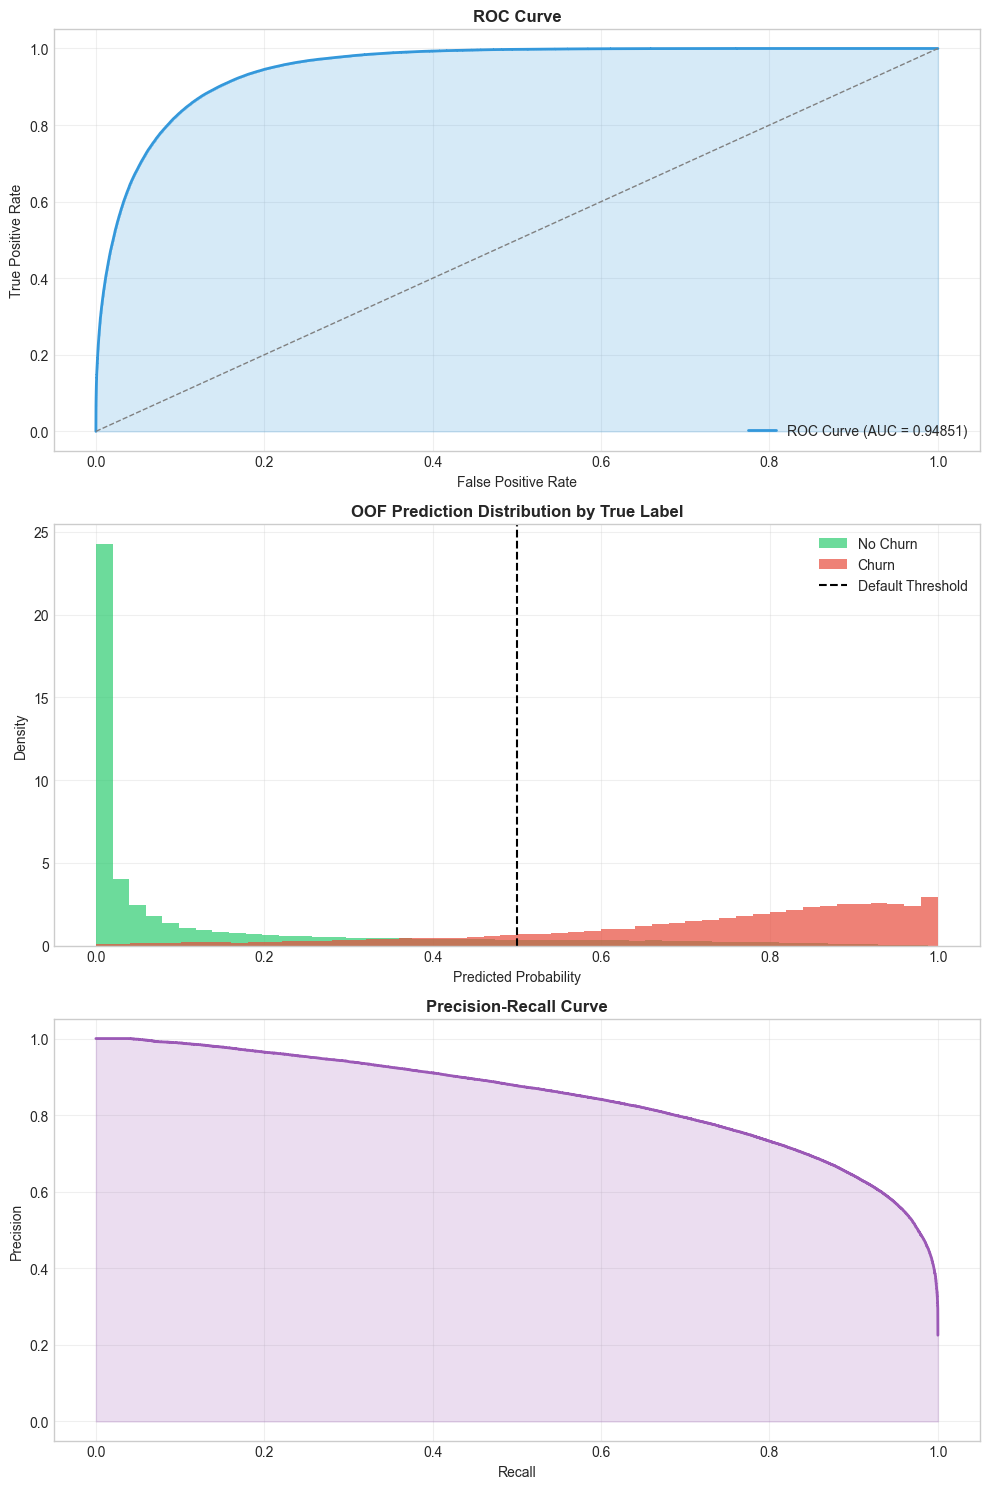

In [31]:
# Visualization: Fold Performance
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 1. ROC Curve
ax2 = axes[0]
fpr, tpr, thresholds = roc_curve(train[CFG.TARGET], oof_ensemble)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.5f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 2. Prediction Distribution
ax3 = axes[1]
ax3.hist(oof_ensemble[train[CFG.TARGET] == 0], bins=50, alpha=0.7, label='No Churn', color='#2ecc71', density=True)
ax3.hist(oof_ensemble[train[CFG.TARGET] == 1], bins=50, alpha=0.7, label='Churn', color='#e74c3c', density=True)
ax3.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Density')
ax3.set_title('OOF Prediction Distribution by True Label', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax4 = axes[2]
precision, recall, _ = precision_recall_curve(train[CFG.TARGET], oof_ensemble)
ax4.plot(recall, precision, color='#9b59b6', linewidth=2)
ax4.fill_between(recall, precision, alpha=0.2, color='#9b59b6')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

Model XGB


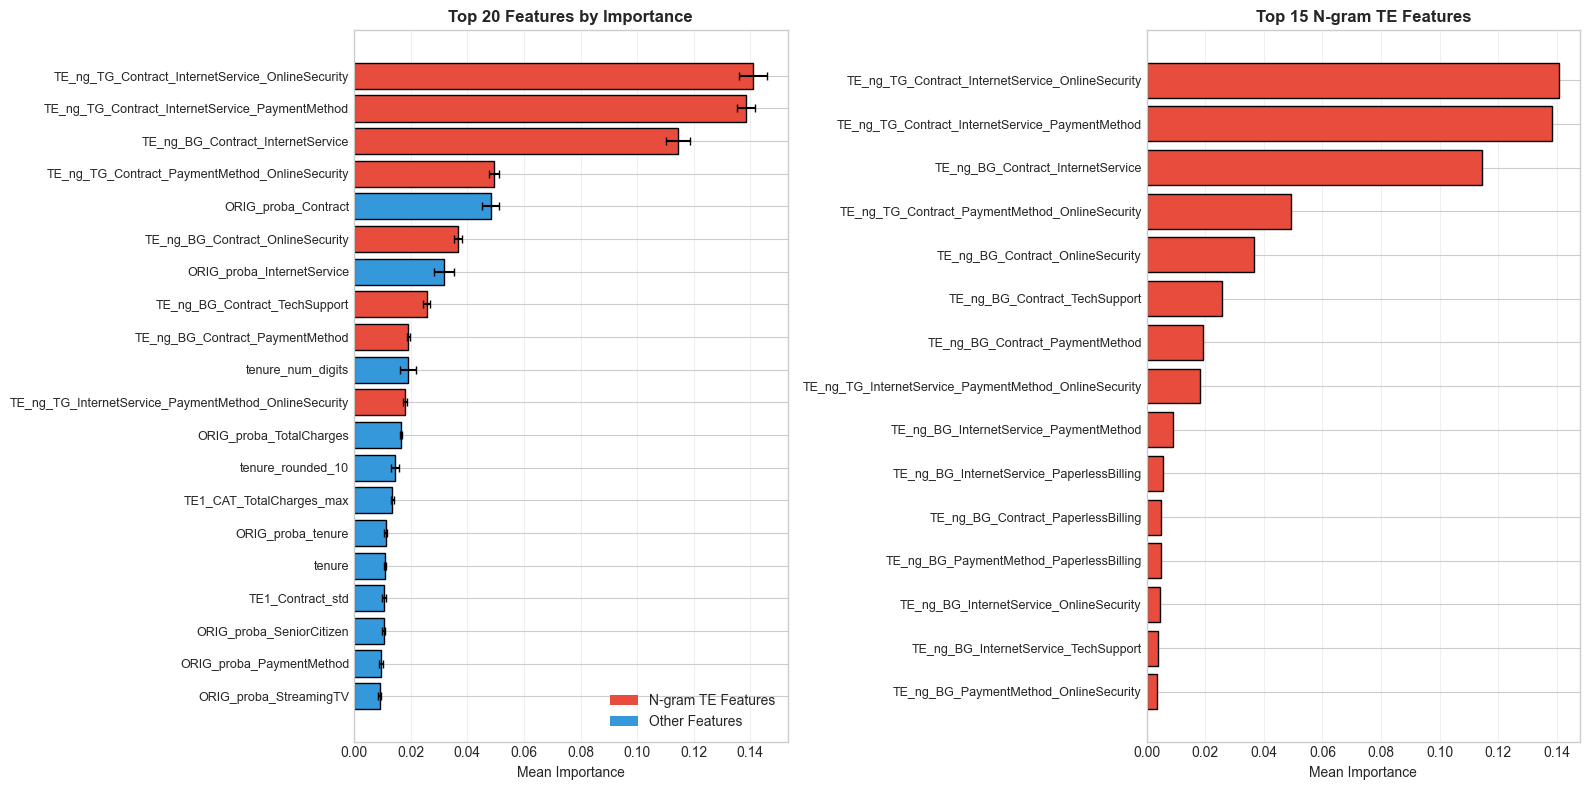


Top 10 N-gram TE Features by Importance:
------------------------------------------------------------
  TE_ng_TG_Contract_InternetService_OnlineSecurity   0.1408
  TE_ng_TG_Contract_InternetService_PaymentMethod    0.1385
  TE_ng_BG_Contract_InternetService                  0.1144
  TE_ng_TG_Contract_PaymentMethod_OnlineSecurity     0.0494
  TE_ng_BG_Contract_OnlineSecurity                   0.0368
  TE_ng_BG_Contract_TechSupport                      0.0257
  TE_ng_BG_Contract_PaymentMethod                    0.0192
  TE_ng_TG_InternetService_PaymentMethod_OnlineSecurity 0.0180
  TE_ng_BG_InternetService_PaymentMethod             0.0089
  TE_ng_BG_InternetService_PaperlessBilling          0.0055
Model CB


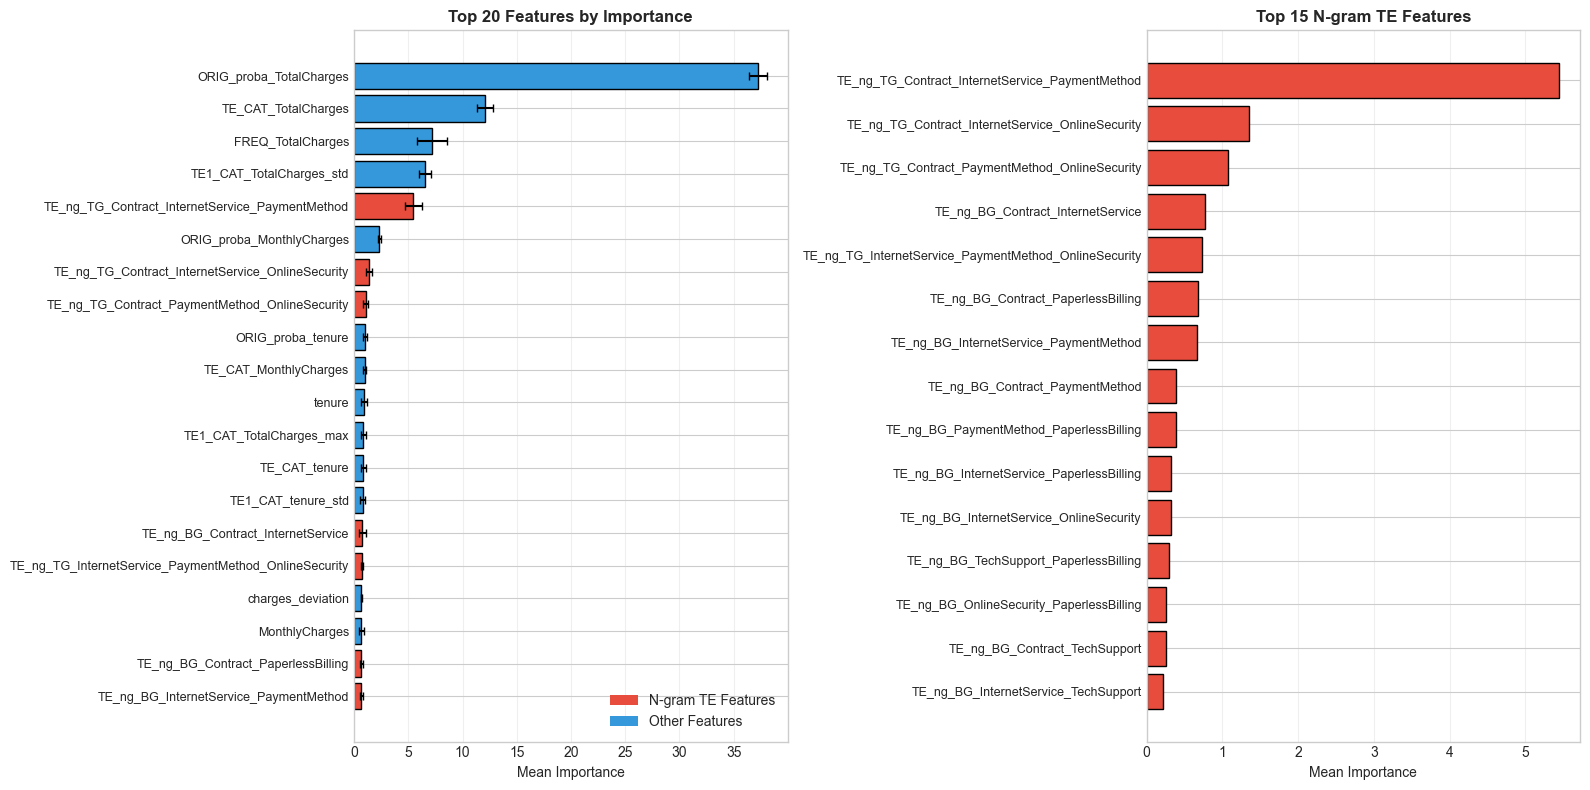


Top 10 N-gram TE Features by Importance:
------------------------------------------------------------
  TE_ng_TG_Contract_InternetService_PaymentMethod    5.4473
  TE_ng_TG_Contract_InternetService_OnlineSecurity   1.3497
  TE_ng_TG_Contract_PaymentMethod_OnlineSecurity     1.0801
  TE_ng_BG_Contract_InternetService                  0.7645
  TE_ng_TG_InternetService_PaymentMethod_OnlineSecurity 0.7254
  TE_ng_BG_Contract_PaperlessBilling                 0.6727
  TE_ng_BG_InternetService_PaymentMethod             0.6677
  TE_ng_BG_Contract_PaymentMethod                    0.3878
  TE_ng_BG_PaymentMethod_PaperlessBilling            0.3853
  TE_ng_BG_InternetService_PaperlessBilling          0.3278


In [27]:
for i, model_name in enumerate(models.keys()):
    # Feature Importance Analysis
    # Calculate mean importance across folds
    print("="*60)
    print(f"Model", model_name)
    feature_importances = fi[model_name]
    imp_cols = [c for c in feature_importances.columns if c.startswith('importance_fold')]
    feature_importances['mean_importance'] = feature_importances[imp_cols].mean(axis=1)
    feature_importances['std_importance'] = feature_importances[imp_cols].std(axis=1)
    feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top 20 features overall
    ax1 = axes[0]
    top20 = feature_importances.head(20)
    colors = ['#e74c3c' if 'TE_ng_' in f else '#3498db' for f in top20['feature']]
    bars = ax1.barh(range(len(top20)), top20['mean_importance'], xerr=top20['std_importance'], 
                   color=colors, edgecolor='black', capsize=3)
    ax1.set_yticks(range(len(top20)))
    ax1.set_yticklabels(top20['feature'], fontsize=9)
    ax1.invert_yaxis()
    ax1.set_xlabel('Mean Importance')
    ax1.set_title('Top 20 Features by Importance', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Legend for colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='N-gram TE Features'),
                       Patch(facecolor='#3498db', label='Other Features')]
    ax1.legend(handles=legend_elements, loc='lower right')
    
    # Top 15 N-gram features
    ax2 = axes[1]
    ngram_imp = feature_importances[feature_importances['feature'].str.startswith('TE_ng_')].head(15)
    bars = ax2.barh(range(len(ngram_imp)), ngram_imp['mean_importance'], 
                   color='#e74c3c', edgecolor='black')
    ax2.set_yticks(range(len(ngram_imp)))
    ax2.set_yticklabels(ngram_imp['feature'], fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlabel('Mean Importance')
    ax2.set_title('Top 15 N-gram TE Features', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print top N-gram features
    print("\nTop 10 N-gram TE Features by Importance:")
    print("-"*60)
    for i, row in ngram_imp.head(10).iterrows():
        print(f"  {row['feature']:50s} {row['mean_importance']:.4f}")

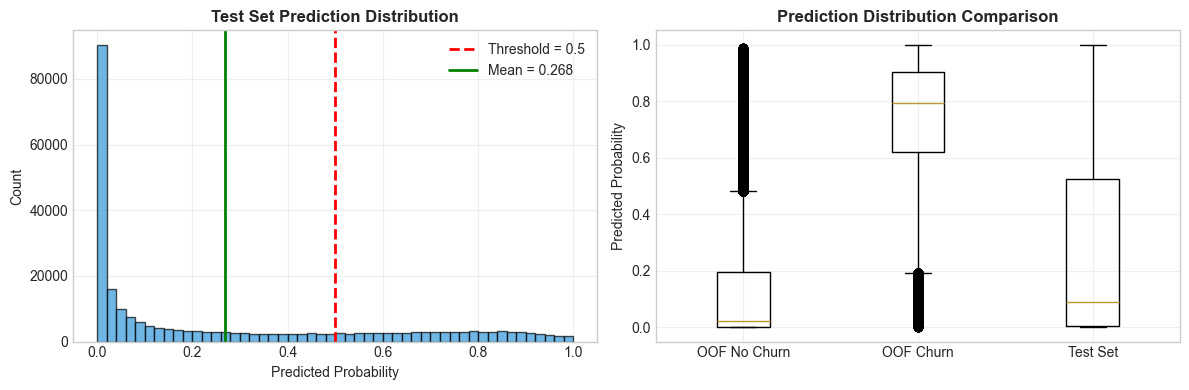


Test Set Statistics:
  Mean prediction: 0.2680
  Std prediction:  0.3156
  Min prediction:  0.0000
  Max prediction:  0.9998
  Predicted churn rate (threshold=0.5): 26.21%


In [32]:
# Test Set Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(pred_ensemble, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].axvline(x=np.mean(pred_ensemble), color='green', linestyle='-', linewidth=2, label=f'Mean = {np.mean(pred_ensemble):.3f}')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
axes[1].boxplot([oof_ensemble[train[CFG.TARGET] == 0], oof_ensemble[train[CFG.TARGET] == 1], pred_ensemble],
               labels=['OOF No Churn', 'OOF Churn', 'Test Set'])
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Prediction Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest Set Statistics:")
print(f"  Mean prediction: {np.mean(pred_ensemble):.4f}")
print(f"  Std prediction:  {np.std(pred_ensemble):.4f}")
print(f"  Min prediction:  {np.min(pred_ensemble):.4f}")
print(f"  Max prediction:  {np.max(pred_ensemble):.4f}")
print(f"  Predicted churn rate (threshold=0.5): {(pred_ensemble >= 0.5).mean()*100:.2f}%")

## 6. Saving Predictions

In [35]:
# Save OOF Predictions
oof_df = pd.DataFrame({
    'id': train_ids,
    CFG.TARGET: oof_ensemble
})
for model_name in models.keys():
    oof_df[CFG.TARGET + '_' + model_name] = oof[model_name]
oof_df.to_csv('oof_predictions.csv', index=False)
print(f"OOF predictions saved to 'oof_predictions.csv'")
print(f"  Shape: {oof_df.shape}")
display(oof_df.head())

# Save Test Predictions (Submission File)
sub_df = pd.DataFrame({
    'id': test_ids,
    CFG.TARGET: pred_ensemble
})
sub_df.to_csv('submission.csv', index=False)
print(f"\nSubmission saved to 'submission.csv'")
print(f"  Shape: {sub_df.shape}")
display(sub_df.head())

OOF predictions saved to 'oof_predictions.csv'
  Shape: (594194, 4)


,id,Churn,Churn_XGB,Churn_CB
0,0,0.000273,0.000050,0.000495
1,1,0.004697,0.001253,0.008141
2,2,0.514499,0.366145,0.662854
3,3,0.777641,0.631300,0.923983
4,4,0.853762,0.770447,0.937078



Submission saved to 'submission.csv'
  Shape: (254655, 2)


,id,Churn
0,594194,0.282245
1,594195,0.001288
2,594196,0.213138
3,594197,0.006259
4,594198,0.682623
